# Segmentación de Instancias y Tracking — CPU vs GPU
| IA 5.2 Computer Vision
| FCEIA - UNR

En esta práctica trabajamos con **YOLO11-seg**, un modelo de **segmentación de instancias**
(devuelve una máscara por objeto, no solo una caja), y le sumamos **tracking multi-objeto**
para seguir cada objeto a lo largo de un video.

Recorremos tres bloques que se construyen uno sobre otro:

| # | Bloque | Pregunta que responde |
|---|---|---|
| 1 | **Segmentación** | ¿Qué objetos hay en el frame y qué píxeles ocupa cada uno? |
| 2 | **Benchmark CPU vs GPU** | ¿Cuánto tarda? ¿Cuánto acelera la GPU? |
| 3 | **Tracking** | ¿Es "el mismo" objeto entre frames? (ID persistente) |

> **Repaso de la teoría (Unidad 6).** El tracker no "ve" el video: en cada frame predice dónde
> debería estar cada objeto con un **filtro de Kalman** y asocia esas predicciones con las
> detecciones nuevas resolviendo un problema de asignación con el **algoritmo Húngaro**.
> Sobre esa base, **ByteTrack** usa solo movimiento (rápido) y **BoT-SORT** agrega apariencia
> (ReID) y compensación de cámara (más robusto, más lento).
>
> Sobre el final dejamos a **SAM3** como concepto: produce máscaras de altísima calidad pero es
> ~30× más lento que YOLO11, por eso acá usamos YOLO11, que corre en tiempo real.

---
## Instalación

In [1]:
# Ejecutar una sola vez
# !pip install ultralytics gdown -q

## Librerías

In [2]:
import time
import numpy as np
import pandas as pd
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

print(f"PyTorch: {torch.__version__}")
HAS_CUDA = torch.cuda.is_available()
print(f"CUDA disponible: {HAS_CUDA}")
if HAS_CUDA:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Dispositivos que vamos a comparar (si no hay GPU, solo CPU)
DEVICES = {"CPU": "cpu"}
if HAS_CUDA:
    DEVICES["GPU"] = 0
print("Dispositivos a evaluar:", list(DEVICES.keys()))

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\const\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.10.0+cpu
CUDA disponible: False
Dispositivos a evaluar: ['CPU']


## Descargar el video

Usamos el mismo video que la teoría (una calle de Shinjuku, con autos y personas).

> Si la descarga falla, podés usar **cualquier** video propio: solo cambiá `VIDEO_PATH`.

In [3]:
import gdown

VIDEO_PATH = "shinjuku.mp4"
file_id = "13d-WecRvyTozDcQrHxLV1t_e5GQzPiPz"   # mismo video que la teoría
gdown.download(f"https://drive.google.com/uc?id={file_id}", VIDEO_PATH, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=13d-WecRvyTozDcQrHxLV1t_e5GQzPiPz
To: c:\Users\const\Documents\Trabajo\Facultad\CV\IA5.2_Computer_Vision\unidad_6\practica\segmentacion_tracking\shinjuku.mp4
100%|██████████| 2.84M/2.84M [00:00<00:00, 25.4MB/s]


'shinjuku.mp4'

In [4]:
cap = cv2.VideoCapture(VIDEO_PATH)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS_SRC = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f"{VIDEO_PATH}: {W}x{H} | {TOTAL_FRAMES} frames | {FPS_SRC:.0f} FPS")

# Para que la práctica sea rápida procesamos solo un tramo del video
N_FRAMES = 50

shinjuku.mp4: 1280x606 | 631 frames | 30 FPS


---
# 1. Segmentación de instancias

Conviene distinguir tres tareas que suelen confundirse:

| Tarea | Salida por objeto | Ejemplo de modelo |
|---|---|---|
| **Detección** | una **caja** (bbox) + clase | Faster R-CNN, YOLO |
| **Segmentación semántica** | una **clase por píxel** (no separa instancias) | DeepLab |
| **Segmentación de instancias** | una **máscara por objeto** + clase | YOLO11-seg, Mask R-CNN, SAM |

YOLO11-seg hace lo último: por cada objeto devuelve caja, clase, score **y** una máscara que
marca exactamente qué píxeles le pertenecen. Cargamos la variante **`yolo11n-seg`**
(`n` = *nano*, la más liviana y rápida) y la corremos sobre el primer frame.

Objetos segmentados en el frame: 5


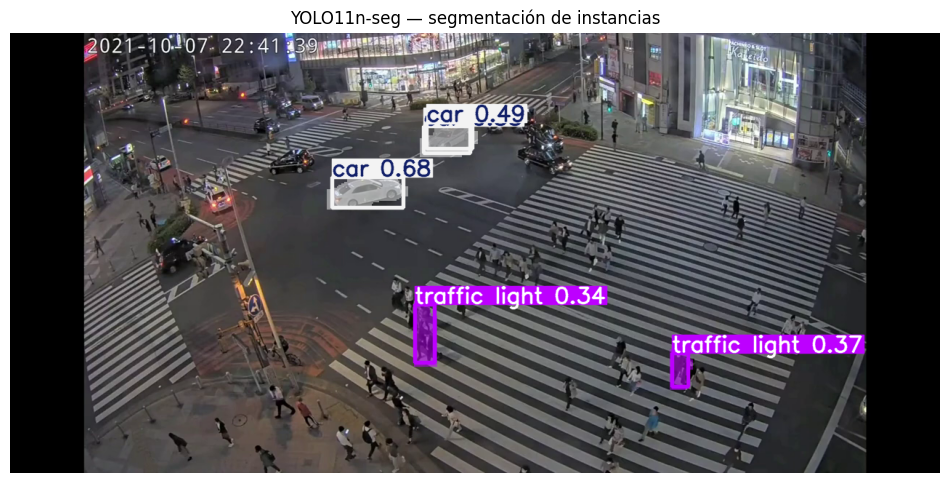

In [5]:
model = YOLO("yolo11n-seg.pt")   # se descarga solo la primera vez

# Tomamos el primer frame del video
cap = cv2.VideoCapture(VIDEO_PATH)
ok, frame = cap.read()
cap.release()

res = model(frame, conf=0.3, verbose=False)[0]
print(f"Objetos segmentados en el frame: {len(res.masks) if res.masks is not None else 0}")

# res.plot() dibuja máscaras + cajas + clases sobre el frame
vis = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 6))
plt.imshow(vis); plt.axis("off")
plt.title("YOLO11n-seg — segmentación de instancias")
plt.show()

## 1.1 ¿Qué hay dentro de un resultado?

Cada resultado de YOLO trae varios objetos que conviene conocer:

- `res.boxes.cls` — el **id de clase** de cada detección
- `res.boxes.conf` — el **score** (confianza)
- `res.masks.data` — las **máscaras** como tensor `(n_objetos, alto, ancho)`
- `res.names` — el diccionario `{id: nombre}` (clases de **COCO**, 80 categorías)

Veamos qué **clases** detectó y cuántas instancias de cada una, y comparemos la imagen
original contra la **unión de todas las máscaras** (esto deja en evidencia que la segmentación
razona a nivel de **píxel**, no de caja).

Instancias por clase:
car              3
traffic light    2


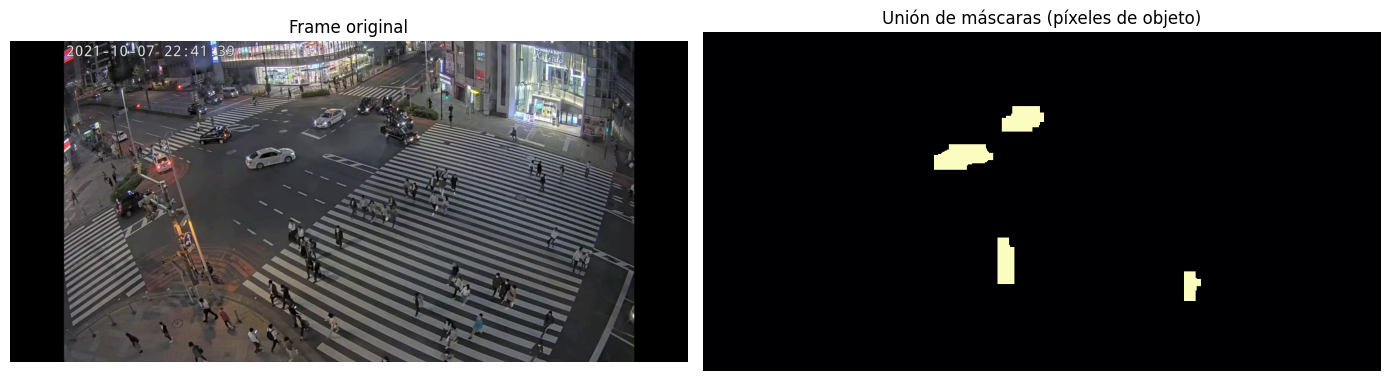

In [6]:
# Conteo de instancias por clase
clases = [res.names[int(c)] for c in res.boxes.cls]
conteo = pd.Series(clases).value_counts()
print("Instancias por clase:")
print(conteo.to_string())

# Unión de todas las máscaras del frame (0/1 por píxel)
mascaras = res.masks.data.cpu().numpy()      # (n, h, w)
union = mascaras.max(axis=0)                  # combinamos todas en una sola

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); axes[0].set_title("Frame original")
axes[1].imshow(union, cmap="magma"); axes[1].set_title("Unión de máscaras (píxeles de objeto)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

---
# 2. Benchmark: CPU vs GPU

Una idea clave: **el hardware no cambia lo que el modelo detecta, solo la velocidad**.
Los mismos pesos producen las mismas máscaras en CPU y en GPU; lo que cambia es cuántos
milisegundos tarda cada frame.

Medimos por dispositivo:
- **latencia por frame** (ms) y su **P95** (el "peor caso" típico, el percentil 95)
- **throughput** (FPS = 1000 / latencia media)
- **máscaras por frame** (para confirmar que la detección no depende del hardware)

In [7]:
def benchmark(model_name, device, n_frames=N_FRAMES, conf=0.3, imgsz=640):
    """Corre YOLO11-seg sobre n_frames y mide la latencia por frame."""
    model = YOLO(model_name)
    cap = cv2.VideoCapture(VIDEO_PATH)

    # Warm-up: la primera inferencia compila kernels y no es representativa
    ok, frame = cap.read()
    if ok:
        model(frame, device=device, imgsz=imgsz, verbose=False)

    lat_ms, n_masks = [], []
    for _ in range(n_frames):
        ok, frame = cap.read()
        if not ok:
            break
        t0 = time.perf_counter()
        r = model(frame, device=device, conf=conf, imgsz=imgsz, verbose=False)[0]
        lat_ms.append((time.perf_counter() - t0) * 1000)
        n_masks.append(len(r.masks) if r.masks is not None else 0)
    cap.release()

    lat = np.array(lat_ms)
    return {
        "lat_ms":     lat,
        "mean_ms":    float(lat.mean()),
        "p95_ms":     float(np.percentile(lat, 95)),
        "fps":        float(1000.0 / lat.mean()),
        "mean_masks": float(np.mean(n_masks)),
    }

In [8]:
results = {}
for label, device in DEVICES.items():
    print(f"Benchmark en {label} ...")
    results[label] = benchmark("yolo11n-seg.pt", device)
    r = results[label]
    print(f"  media={r['mean_ms']:6.1f} ms | P95={r['p95_ms']:6.1f} ms | "
          f"{r['fps']:5.1f} FPS | máscaras/frame={r['mean_masks']:.1f}")

Benchmark en CPU ...
  media=  87.4 ms | P95=  95.9 ms |  11.4 FPS | máscaras/frame=3.2


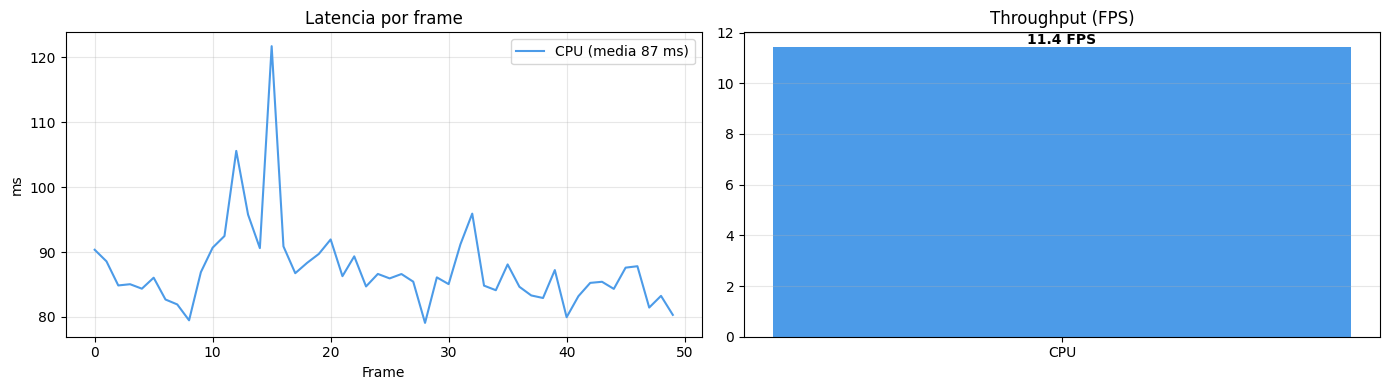

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
labels  = list(results.keys())
colores = {"CPU": "#4C9BE8", "GPU": "#F2A541"}

# Latencia por frame
for label in labels:
    axes[0].plot(results[label]["lat_ms"], color=colores.get(label),
                 label=f"{label} (media {results[label]['mean_ms']:.0f} ms)")
axes[0].set_title("Latencia por frame"); axes[0].set_xlabel("Frame")
axes[0].set_ylabel("ms"); axes[0].legend(); axes[0].grid(alpha=0.3)

# FPS comparativo
fps_vals = [results[l]["fps"] for l in labels]
bars = axes[1].bar(labels, fps_vals, color=[colores.get(l) for l in labels], width=0.5)
axes[1].bar_label(bars, fmt="%.1f FPS", fontweight="bold")
axes[1].set_title("Throughput (FPS)"); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()

In [10]:
# Tabla resumen
tabla = pd.DataFrame({
    label: {
        "Media (ms)":     round(r["mean_ms"], 1),
        "P95 (ms)":       round(r["p95_ms"], 1),
        "FPS":            round(r["fps"], 1),
        "Máscaras/frame": round(r["mean_masks"], 1),
    }
    for label, r in results.items()
}).T
if {"CPU", "GPU"}.issubset(results):
    tabla["Speedup vs CPU"] = (results["CPU"]["mean_ms"] /
                               tabla.index.map(lambda l: results[l]["mean_ms"])).round(1)
tabla

,Media (ms),P95 (ms),FPS,Máscaras/frame
CPU,87.4,95.9,11.4,3.2


#### Análisis

- **Las máscaras por frame son (casi) iguales en CPU y GPU**: el hardware no cambia *qué*
  se detecta, solo la velocidad. Pequeñas diferencias pueden venir de redondeos en FP16.
- En **GPU** el mismo modelo suele correr **entre 5× y 40× más rápido**: cuanto más grande
  la red, más se beneficia del paralelismo (lo vas a comprobar en el Ejercicio 1).
- La **P95** es interesante: en CPU suele ser bastante mayor que la media (latencia con "colas"
  largas en frames complejos), mientras que en GPU P95 ≈ media (mucho más predecible).

> **Si solo tenés CPU** (por ejemplo, corriendo localmente sin GPU) vas a ver un único color
> y sin columna de speedup. En Colab podés activar GPU en *Entorno de ejecución → Cambiar tipo*.

---
# 3. Tracking multi-objeto

Hasta acá detectamos objetos **frame por frame**, sin memoria: en el frame 10 no sabemos
si un auto es "el mismo" que vimos en el frame 9.

El **tracking** resuelve eso asignando un **ID persistente** a cada objeto. Con
`model.track(..., persist=True)` Ultralytics aplica internamente el ciclo que vimos en teoría:

```
detección (YOLO) → predicción (Kalman) → asociación (algoritmo Húngaro) → actualizar IDs
```

## 3.1 ByteTrack vs BoT-SORT

Ultralytics trae dos trackers listos para usar:

| Propiedad | **ByteTrack** | **BoT-SORT** |
|---|---|---|
| Señal de asociación | solo movimiento (IoU) | movimiento **+ apariencia (ReID)** |
| Compensación de cámara | ❌ | ✅ (GMC) |
| Velocidad | muy rápido | más lento |
| Mejor para | cámara fija, multitudes | cámara en movimiento, oclusiones largas |
| Config en Ultralytics | `"bytetrack.yaml"` | `"botsort.yaml"` |

Probamos **ByteTrack**, contamos los IDs únicos del tramo y registramos cuántos objetos
hay activos en cada frame.

In [11]:
def trackear(tracker, n_frames=N_FRAMES, device=list(DEVICES.values())[-1], conf=0.3):
    """Corre YOLO11-seg + tracker. Devuelve (n_ids_unicos, tracks_por_frame, ultimo_vis)."""
    model = YOLO("yolo11n-seg.pt")
    cap = cv2.VideoCapture(VIDEO_PATH)
    ids, por_frame, ultimo_vis = set(), [], None
    for _ in range(n_frames):
        ok, frame = cap.read()
        if not ok:
            break
        r = model.track(frame, persist=True, tracker=tracker,
                        device=device, conf=conf, verbose=False)[0]
        frame_ids = r.boxes.id.int().tolist() if r.boxes.id is not None else []
        ids.update(frame_ids)
        por_frame.append(len(frame_ids))
        ultimo_vis = r.plot()
    cap.release()
    return len(ids), por_frame, ultimo_vis

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: c:\Users\const\Documents\Trabajo\Facultad\CV\IA5.2_Computer_Vision\.venv
Resolved 2 packages in 840ms
 Downloaded lap
Prepared 1 package in 215ms
Installed 1 package in 40ms
 + lap==0.5.13

requirements: AutoUpdate success  1.6s
WARNING requirements: Restart runtime or rerun command for updates to take effect

ByteTrack — IDs únicos en 50 frames: 10


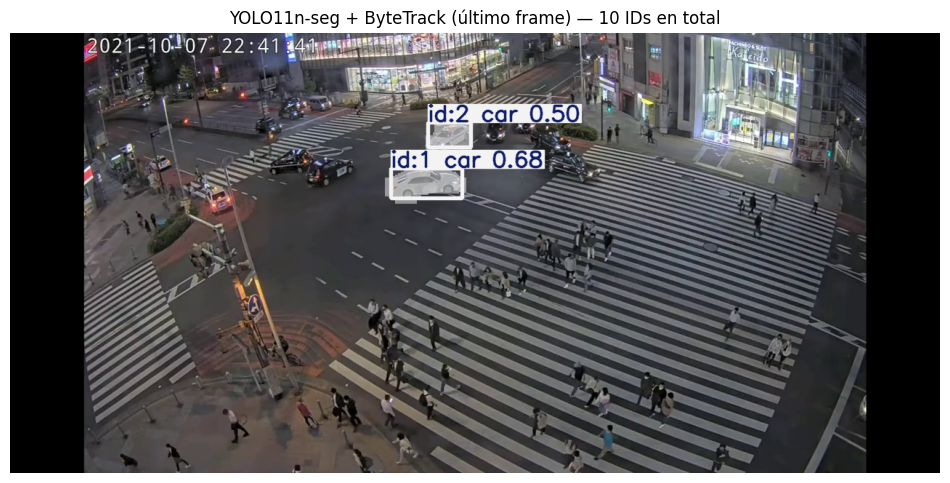

In [12]:
device = list(DEVICES.values())[-1]   # usa GPU si hay, si no CPU
n_ids, tracks_pf, vis = trackear("bytetrack.yaml", device=device)
print(f"ByteTrack — IDs únicos en {N_FRAMES} frames: {n_ids}")

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title(f"YOLO11n-seg + ByteTrack (último frame) — {n_ids} IDs en total")
plt.show()

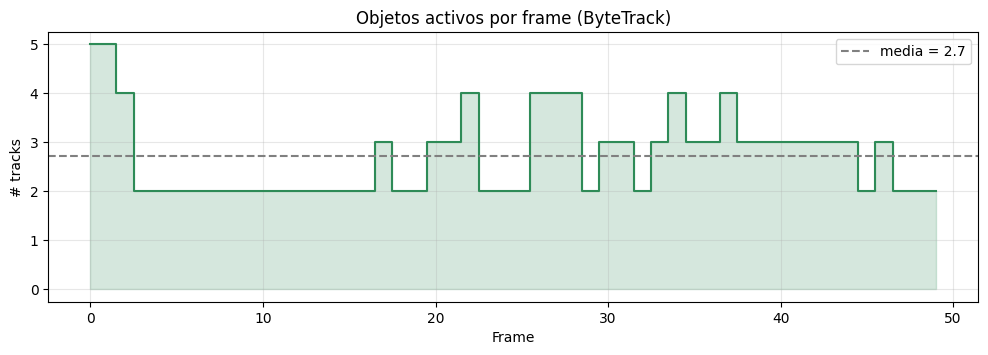

In [13]:
# Objetos activos por frame
plt.figure(figsize=(12, 3.5))
plt.step(range(len(tracks_pf)), tracks_pf, where="mid", color="seagreen")
plt.fill_between(range(len(tracks_pf)), tracks_pf, step="mid", alpha=0.2, color="seagreen")
plt.axhline(np.mean(tracks_pf), ls="--", color="gray",
            label=f"media = {np.mean(tracks_pf):.1f}")
plt.title("Objetos activos por frame (ByteTrack)")
plt.xlabel("Frame"); plt.ylabel("# tracks"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

#### Análisis

Cada caja ahora lleva un número de **ID** además de la clase. Si el tracking fuera perfecto,
la cantidad de IDs únicos sería igual a la cantidad real de objetos distintos que pasaron por
la escena. En la práctica, las **oclusiones** y los **cambios de escala** hacen que a veces un
mismo objeto reciba un ID nuevo (un *ID switch*), inflando el conteo de IDs únicos.

El gráfico de **objetos activos por frame** sigue la complejidad de la escena: sube cuando hay
más gente/autos en cuadro. Comparalo con la curva de latencia del bloque 2 — suelen estar
correlacionadas (más objetos ⇒ más trabajo de post-procesado ⇒ frames más lentos).

---
# 4. ¿Y SAM3? (concepto)

En la teoría vimos **SAM3** (Segment Anything Model 3, Meta). ¿Por qué no lo corremos acá?

| | **YOLO11-seg** | **SAM3** |
|---|---|---|
| Filosofía | máscaras livianas ancladas a la caja | máscaras densas de un encoder ViT |
| Calidad de máscara | buena | **excelente** (bordes finos) |
| Velocidad (GPU) | ~20–45 ms/frame (tiempo real) | ~1500 ms/frame (**~30× más lento**) |
| Acceso a pesos | abiertos (se bajan solos) | *gated* (requiere token de Hugging Face) |
| Uso ideal | video en tiempo real | segmentación offline de altísima calidad |

**Conclusión práctica:** para video en vivo (vigilancia, conteo, tracking) se usa YOLO; SAM3
brilla cuando importa la **calidad de la máscara** y se puede procesar offline. Un patrón común
es combinarlos: YOLO detecta rápido y SAM refina la máscara solo donde hace falta.

> La implementación completa de SAM3 sobre este mismo video está en el **notebook de teoría**
> de la Unidad 6 (`class_7_CPU_vs_GPU_YOLOV11_vs_SAM3_.ipynb`).

---
# Ejercicios

Cada ejercicio tiene una celda con el código comentado como guía.
Descomentá, completá los huecos y ejecutá.

## Ejercicio 1 — ¿Cuánto cuesta un modelo más grande?

YOLO11-seg viene en varios tamaños: `n` (nano), `s`, `m`, `l`, `x` (extra-large).
Corré el benchmark con **`yolo11m-seg.pt`** y compará contra `yolo11n-seg.pt`.

1. Llamá a `benchmark("yolo11m-seg.pt", device)` para cada dispositivo de `DEVICES`
2. Imprimí media de latencia y FPS
3. Respondé: ¿cuántas veces más lento es `m` que `n`? ¿La diferencia es igual en CPU que en GPU?

> **Tip:** la primera vez se descargan los pesos de `yolo11m-seg` (es más pesado que `n`).

In [14]:
# Ejercicio 1 — completar aquí

# for label, device in DEVICES.items():
#     r = benchmark("yolo11m-seg.pt", device)
#     print(f"{label}: media={r['mean_ms']:.1f} ms | {r['fps']:.1f} FPS")

# Comparar con results['CPU'] / results['GPU'] (yolo11n) calculados en el bloque 2

## Ejercicio 2 — ByteTrack vs BoT-SORT

Volvé a trackear pero ahora con **`botsort.yaml`** y compará con ByteTrack.

1. Llamá a `trackear("botsort.yaml", device=device)`
2. Compará el número de IDs únicos y la curva de tracks por frame contra ByteTrack
3. Respondé: ¿da más o menos IDs? Recordá que BoT-SORT usa apariencia (ReID) y compensación
   de cámara — ¿esperarías **menos** *ID switches* en escenas con oclusiones?

In [15]:
# Ejercicio 2 — completar aquí

# n_ids_bot, tracks_bot, vis_bot = trackear("botsort.yaml", device=device)
# print(f"BoT-SORT  — IDs únicos: {n_ids_bot}")
# print(f"ByteTrack — IDs únicos: {n_ids}")

# Opcional: graficar las dos curvas de tracks por frame superpuestas

## Ejercicio 3 — Efecto del tamaño de entrada (`imgsz`)

YOLO redimensiona cada frame a `imgsz × imgsz` antes de inferir. Un `imgsz` más grande
detecta mejor los objetos chicos, pero cuesta más (la latencia crece ~cuadráticamente).

1. Corré `benchmark("yolo11n-seg.pt", device, imgsz=320)` y `imgsz=1280`
2. Compará latencia media y **máscaras detectadas por frame** (`mean_masks`)
3. Respondé: ¿con `imgsz` grande se detectan más objetos? ¿Cuánto más caro sale?

> **Tip:** `imgsz` debe ser múltiplo de 32.

In [16]:
# Ejercicio 3 — completar aquí

# for size in (320, 1280):
#     r = benchmark("yolo11n-seg.pt", device, imgsz=size)
#     print(f"imgsz={size}: media={r['mean_ms']:.1f} ms | "
#           f"máscaras/frame={r['mean_masks']:.1f}")

## Ejercicio 4 — Segmentar solo una clase

A veces solo nos interesan ciertos objetos (por ejemplo, **personas**). YOLO permite filtrar
por clase con el parámetro `classes` (en COCO, la clase `0` es *person* y la `2` es *car*).

1. Tomá el primer frame del video (como en el bloque 1)
2. Corré `model(frame, conf=0.3, classes=[0], verbose=False)[0]`
3. Visualizá el resultado con `res.plot()` y contá cuántas personas hay
4. (Opcional) Probá `classes=[2]` (*car*) y compará

> **Tip:** podés ver el mapeo id→clase con `model.names`.

In [17]:
# Ejercicio 4 — completar aquí

# cap = cv2.VideoCapture(VIDEO_PATH); ok, frame = cap.read(); cap.release()
# res = model(frame, conf=0.3, classes=[0], verbose=False)[0]
# print("Personas:", len(res.masks) if res.masks is not None else 0)
# plt.figure(figsize=(12, 6))
# plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

## Ejercicio 5 — Guardar el video anotado

Hasta ahora visualizamos frames sueltos. Generá un **video de salida** con las máscaras y los
IDs dibujados, para poder reproducirlo después.

1. Abrí el video con `cv2.VideoCapture` y creá un `cv2.VideoWriter` (mismo `W`, `H`, `FPS_SRC`)
2. Para cada frame, corré `model.track(..., persist=True)` y obtené `r.plot()`
3. Escribí cada frame anotado con `writer.write(...)` y al final `writer.release()`
4. (En Colab) descargá el archivo con `from google.colab import files; files.download(...)`

> **Tip:** el codec `cv2.VideoWriter_fourcc(*"mp4v")` y la extensión `.mp4` funcionan bien.

In [18]:
# Ejercicio 5 — completar aquí

# out_path = "salida_tracking.mp4"
# writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), FPS_SRC, (W, H))
# model = YOLO("yolo11n-seg.pt")
# cap = cv2.VideoCapture(VIDEO_PATH)
# for _ in range(N_FRAMES):
#     ok, frame = cap.read()
#     if not ok: break
#     r = model.track(frame, persist=True, tracker="bytetrack.yaml",
#                     device=device, conf=0.3, verbose=False)[0]
#     writer.write(r.plot())
# cap.release(); writer.release()
# print("Guardado en", out_path)

---
# Conclusiones

- **Segmentación de instancias** = una máscara por objeto, no solo una caja. YOLO11-seg la
  produce en tiempo real entregando `boxes`, `masks`, `conf` y `names` por frame.
- El **hardware no cambia qué se detecta, solo qué tan rápido**: en GPU el mismo modelo corre
  muchas veces más rápido y con latencia más predecible (P95 ≈ media); los modelos grandes son
  los que más se benefician.
- El **tracking** agrega memoria temporal (IDs persistentes) combinando **Kalman + Húngaro**;
  **ByteTrack** prioriza velocidad y **BoT-SORT** robustez ante oclusiones y cámara en movimiento.
- Hay un **trade-off** constante entre precisión, velocidad y tamaño de entrada (`imgsz`).

| Prioridad | Elección sugerida |
|---|---|
| Tiempo real en GPU | `yolo11n/m-seg` |
| Máxima precisión (offline) | `yolo11x-seg` o SAM3 |
| Cámara estática, multitud | ByteTrack |
| Cámara en movimiento / oclusiones largas | BoT-SORT |
| Máscaras de altísima calidad | SAM3 (lento, no tiempo real) |

**Conceptos clave de esta práctica:** segmentación de instancias vs. semántica · latencia,
P95 y throughput (FPS) · speedup CPU→GPU · tracking por detección con Kalman + algoritmo Húngaro
· ByteTrack vs. BoT-SORT · trade-offs de `imgsz` y tamaño de modelo.